# Lesson 12 — Mini Project: Train a Tiny Neural Network End-to-End

到目前为止，我们已经分别学习了：

- Tensor
- Broadcasting
- Matrix Multiplication
- `einsum`
- Autograd
- `nn.Module`
- Linear Layer
- Embedding
- Softmax
- Cross Entropy
- SGD
- Adam / AdamW
- Basic Training Loop

这些知识如果一直停留在彼此独立的小实验里，还不能真正形成一个完整的 Deep Learning Workflow。

这一节的目标是把它们第一次连接成一个完整系统：

```text
Dataset
   ↓
DataLoader
   ↓
Mini-Batch
   ↓
Model
   ↓
Logits
   ↓
Loss
   ↓
Backward
   ↓
Gradients
   ↓
Optimizer
   ↓
Parameter Update
   ↓
Evaluation
   ↓
Checkpoint
   ↓
Inference
```

这一节真正重要的不是训练出一个复杂模型，而是建立一种以后做 CS336 时会一直使用的工程习惯：

> Correctness before long-running experiments.

也就是说，在开始正式训练之前，先逐个验证：

```text
Data
→ Shape
→ Forward
→ Loss
→ Backward
→ Gradient
→ Optimizer
```

## 1. Mini Project 目标

我们训练一个非常小的二分类 Neural Network。

输入是二维向量：

$$
x=(x_1,x_2)
$$

因此 Feature Dimension 为：

$$
D_{in}=2
$$

输出有两个类别：

$$
C=2
$$

模型结构：

```text
Input
  2
  ↓
Linear
  ↓
ReLU
  ↓
Hidden
  ↓
Linear
  ↓
ReLU
  ↓
Hidden
  ↓
Linear
  ↓
Logits
  2
```

也就是：

$$
2\rightarrow H\rightarrow H\rightarrow2
$$

这个模型虽然很小，但已经包含完整训练所需的核心组件。

## 2. 本节学习目标

完成本节后，应能够独立解释并实现：

1. 如何组织一个可重复的 Experiment；
2. Dataset 与 DataLoader 的职责；
3. Mini-Batch Shape 如何形成；
4. `nn.Module` 如何组成完整 Model；
5. Logits 和 Class Target 的 Shape；
6. Cross Entropy 如何连接 Model 与 Label；
7. `loss.backward()` 后 Gradient 存在哪里；
8. 为什么必须在每次训练 Step 前清理 Gradient；
9. AdamW 如何更新 Parameter；
10. 如何组织 `train_one_epoch()`；
11. 如何组织 `evaluate()`；
12. 如何记录 Training History；
13. 如何保存 Best Validation Checkpoint；
14. 如何重新加载 Model；
15. 如何进行 Inference；
16. 如何进行 Reproducibility Test；
17. 如何进行 Reference Test；
18. 如何进行 Overfit-One-Batch Test。

最终应该能够从头解释：

```text
model.train()
optimizer.zero_grad()
logits = model(x)
loss = criterion(logits, y)
loss.backward()
optimizer.step()
```

每一行分别在做什么。


In [1]:
from __future__ import annotations

import math
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset


## 4. Experiment Configuration

正式实验中，不建议把 Hyperparameters 散落在 Notebook 各处。

例如下面这种写法很容易失控：

```text
这里 batch_size = 32
下面 learning_rate = 1e-3
另一个 Cell 又写 epochs = 20
```

更合理的方式是集中管理配置。

这一节使用 `dataclass`：

```text
Config
├── seed
├── dataset_size
├── validation_fraction
├── input_dim
├── hidden_dim
├── num_classes
├── batch_size
├── epochs
├── learning_rate
├── weight_decay
└── checkpoint_path
```

这样以后做 Transformer 实验时，也可以延续相同思路。

In [2]:
@dataclass(frozen=True)
class Config:
    seed: int = 42

    dataset_size: int = 2_000
    validation_fraction: float = 0.2

    input_dim: int = 2
    hidden_dim: int = 64
    num_classes: int = 2

    batch_size: int = 64
    epochs: int = 30

    learning_rate: float = 3e-3
    weight_decay: float = 1e-4

    checkpoint_path: str = "checkpoints/tiny_classifier.pt"


config = Config()
config

Config(seed=42, dataset_size=2000, validation_fraction=0.2, input_dim=2, hidden_dim=64, num_classes=2, batch_size=64, epochs=30, learning_rate=0.003, weight_decay=0.0001, checkpoint_path='checkpoints/tiny_classifier.pt')

## 5. Reproducibility 与 Random Seed

训练 Neural Network 中存在很多随机过程：

- Dataset generation
- Train / Validation split
- Weight initialization
- DataLoader shuffle

因此我们固定 Random Seed。

但要注意：

> 固定 Seed 不等于在所有硬件、所有 PyTorch 版本、所有 CUDA Kernel 上实现绝对 bitwise reproducibility。

这里的目标是：

```text
尽可能稳定地复现实验行为
```

而不是承诺所有环境完全逐 bit 一致。

In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(config.seed)

## 6. Device Selection

我们的代码不应该假设一定存在 CUDA。

采用：

```text
CUDA available
    ↓ yes
   cuda
    ↓ no
   cpu
```

这也是以后写正式模型时应该保持的习惯：

> Device agnostic.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 7. 构造一个可学习的 Dataset

为了把注意力集中在 Training Pipeline，而不是数据处理上，我们构造二维 Synthetic Dataset。

每个样本：

$$
x=(x_1,x_2)
$$

Shape：

```text
Single feature: (2,)
```

我们定义分类规则：

$$
y=
\begin{cases}
1,&x_1^2+x_2^2>1\\
0,&\text{otherwise}
\end{cases}
$$

因此 Model 需要学习一个非线性边界。

这比简单的：

$$
x_1+x_2>0
$$

更适合验证隐藏层和 Activation 是否真的发挥作用。

In [5]:
def make_dataset(num_samples: int, seed: int) -> tuple[torch.Tensor, torch.Tensor]:
    generator = torch.Generator().manual_seed(seed)

    features = torch.rand(num_samples, 2, generator=generator) * 4.0 - 2.0

    radius_squared = features[:, 0] ** 2 + features[:, 1] ** 2

    targets = (radius_squared > 1.0).long()

    return features, targets


features, targets = make_dataset(config.dataset_size, config.seed)

print("features:", features.shape)
print("targets :", targets.shape)

features: torch.Size([2000, 2])
targets : torch.Size([2000])


## 8. Dataset Shape Thinking

当前：

$$
features.shape=(N,2)
$$

其中：

- $N$：Number of Samples
- $2$：Feature Dimension

Target：

$$
targets.shape=(N,)
$$

注意这里 Target 不是：

```text
(N, 1)
```

也不是：

```text
(N, 2)
```

Cross Entropy 的 class-index target 通常是：

```text
(N,)
```

而每个元素是：

```text
0 或 1
```

因此我们现在已经有第一组重要 Shape：

```text
Features: (N, 2)
Targets : (N,)
```


## 9. 永远先检查 Data

在训练开始前先检查：

```text
Shape
dtype
NaN / Inf
Label range
Class distribution
```

一个常见错误是：

```text
Loss 不下降
→ 立刻调 Learning Rate
```

但实际上可能只是：

- Label 越界；
- Feature 中有 NaN；
- Dataset 全是同一个类别；
- dtype 错误；
- Shape 错误。

所以第一原则：

> Debug training from the data outward.

In [6]:
assert features.ndim == 2
assert features.shape[1] == config.input_dim

assert targets.ndim == 1
assert targets.shape[0] == features.shape[0]

assert features.dtype.is_floating_point
assert targets.dtype == torch.long

assert torch.isfinite(features).all()

assert targets.min().item() >= 0
assert targets.max().item() < config.num_classes

class_counts = torch.bincount(targets, minlength=config.num_classes)

print("Class counts:", class_counts)
print("Class ratio:", class_counts.float() / class_counts.sum())

Class counts: tensor([ 405, 1595])
Class ratio: tensor([0.2025, 0.7975])


## 10. 为什么需要 Validation Set？

Training Set 用于 Parameter Update。

Validation Set 用于回答：

> Model 对没有参与参数更新的数据表现如何？

因此：

```text
Training Data
    ↓
Gradient + Parameter Update
```

而：

```text
Validation Data
    ↓
Only Evaluation
```

Validation 时：

```text
不 backward
不 optimizer.step
```

这两条非常重要。

In [7]:
num_samples = features.shape[0]

num_validation = int(num_samples * config.validation_fraction)
num_train = num_samples - num_validation

generator = torch.Generator().manual_seed(config.seed)

permutation = torch.randperm(num_samples, generator=generator)

train_indices = permutation[:num_train]
validation_indices = permutation[num_train:]

train_features = features[train_indices]
train_targets = targets[train_indices]

validation_features = features[validation_indices]
validation_targets = targets[validation_indices]

print("Train:", train_features.shape, train_targets.shape)
print("Validation:", validation_features.shape, validation_targets.shape)

Train: torch.Size([1600, 2]) torch.Size([1600])
Validation: torch.Size([400, 2]) torch.Size([400])


## 11. Dataset 的职责

`Dataset` 的核心问题是：

> 给我索引 `i`，返回第 `i` 个 Sample。

所以：

```text
Dataset
├── __len__()
└── __getitem__()
```

对于本项目：

```text
feature.shape = (2,)
target.shape  = ()
```

为什么 Target Shape 是 `()`？

因为：

```python
targets[index]
```

取出的是一个 Scalar Tensor。

之后 DataLoader 会把多个 Scalar Target stack 成：

```text
(B,)
```

In [8]:
class ClassificationDataset(Dataset[tuple[torch.Tensor, torch.Tensor]]):
    def __init__(self, features: torch.Tensor, targets: torch.Tensor) -> None:
        self.features = features
        self.targets = targets

    def __len__(self) -> int:
        return self.features.shape[0]

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        return (self.features[index], self.targets[index])


train_dataset = ClassificationDataset(train_features, train_targets)
validation_dataset = ClassificationDataset(validation_features, validation_targets)


In [9]:
sample_features, sample_target = train_dataset[0]

print("Feature shape:", sample_features.shape)
print("Target shape:", sample_target.shape)
print("Target:", sample_target)

Feature shape: torch.Size([2])
Target shape: torch.Size([])
Target: tensor(1)


## 12. Single Sample → Mini-Batch

Dataset 返回一个 Sample：

```text
Feature: (2,)
Target : ()
```

DataLoader 将 $B$ 个 Sample stack：

```text
Feature:
(2,)
  ↓ stack B samples
(B, 2)
```

Target：

```text
()
 ↓ stack B samples
(B,)
```

所以 Mini-Batch Shape：

$$
X.shape=(B,2)
$$

$$
y.shape=(B,)
$$

以后 Language Model 中同一个逻辑会变成：

```text
Single token sequence: (T,)
Batch of sequences   : (B, T)
```

In [10]:
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
validation_loader = DataLoader(
    validation_dataset, batch_size=config.batch_size, shuffle=False
)

batch_features, batch_targets = next(iter(train_loader))

print("Batch features:", batch_features.shape)
print("Batch targets:", batch_targets.shape)

Batch features: torch.Size([64, 2])
Batch targets: torch.Size([64])


## 14. TinyClassifier

Model：

$$
2\rightarrow H\rightarrow H\rightarrow2
$$

其中：

```text
Input Feature
   ↓
Linear(2, H)
   ↓
ReLU
   ↓
Linear(H, H)
   ↓
ReLU
   ↓
Linear(H, 2)
   ↓
Logits
```

最后一层输出：

```text
2 logits
```

分别对应两个类别。

非常重要：

> 最后一层不要手动加 Softmax。

因为 `CrossEntropyLoss` 直接接受 raw logits。

In [11]:
class TinyClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_classes: int) -> None:
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


model = TinyClassifier(
    input_dim=config.input_dim,
    hidden_dim=config.hidden_dim,
    num_classes=config.num_classes,
).to(device)

model

TinyClassifier(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)

## 15. 手算 Parameter Count

第一层：

$$
Linear(2,H)
$$

Parameter：

$$
2H+H=3H
$$

第二层：

$$
Linear(H,H)
$$

Parameter：

$$
H^2+H
$$

第三层：

$$
Linear(H,2)
$$

Parameter：

$$
2H+2
$$

总数：

$$
3H+(H^2+H)+(2H+2)
$$

整理：

$$
H^2+6H+2
$$

如果：

$$
H=64
$$

则：

$$
64^2+6\times64+2
$$

$$
=4096+384+2
$$

$$
=4482
$$

Parameter Count 是后面 LLM Resource Accounting 的基础能力。

In [12]:
parameter_count = sum(parameter.numel() for parameter in model.parameters())
expected_parameter_count = config.hidden_dim**2 + 6 * config.hidden_dim + 2

print("Actual:", parameter_count)
print("Expected:", expected_parameter_count)

assert parameter_count == expected_parameter_count

Actual: 4482
Expected: 4482


In [13]:
batch_features = batch_features.to(device)
batch_targets = batch_targets.to(device)

logits = model(batch_features)

print("Input:", batch_features.shape)
print("Logits:", logits.shape)

assert logits.shape == (batch_features.shape[0], config.num_classes)


Input: torch.Size([64, 2])
Logits: torch.Size([64, 2])


## 17. Forward 不仅要检查 Shape

正确 Shape 不代表 Numerical Values 一定正确。

还应该检查：

```text
NaN?
Inf?
```

因此：

```python
torch.isfinite(logits).all()
```

是一个非常便宜但很有价值的 Sanity Check。

以后 Transformer 中如果出现：

```text
Loss = NaN
```

应该沿着 Forward Pipeline 往前检查：

```text
Embedding
→ Attention
→ MLP
→ Logits
→ Loss
```

找出第一个产生 non-finite value 的位置。

In [14]:
assert torch.isfinite(logits).all()

print("Logits are finite:", torch.isfinite(logits).all().item())

Logits are finite: True


## 18. Loss Shape

我们的 Logits：

$$
logits.shape=(B,C)
$$

这里：

$$
C=2
$$

Targets：

$$
targets.shape=(B,)
$$

每个 Target 是：

```text
class index
```

即：

```text
0
或
1
```

因此：

```text
Logits : (B, 2), floating point
Targets: (B,), integer class index
```

这正是 `CrossEntropyLoss` 的标准输入形式。

In [15]:
criterion = nn.CrossEntropyLoss()

loss = criterion(logits, batch_targets)

print("Loss:", loss)
print("Loss shape:", loss.shape)

assert loss.ndim == 0
assert torch.isfinite(loss)


Loss: tensor(0.7707, device='cuda:0', grad_fn=<NllLossBackward0>)
Loss shape: torch.Size([])


## 19. 为什么 Loss 是 Scalar？

`CrossEntropyLoss` 默认：

```text
reduction="mean"
```

对于 Batch 中每个样本：

$$
\ell_1,\ell_2,\ldots,\ell_B
$$

最终：

$$
L=
\frac{1}{B}
\sum_{i=1}^{B}\ell_i
$$

所以输出 Shape：

```text
()
```

也就是 Scalar Tensor。

这非常适合作为：

```python
loss.backward()
```

的起点。


## 20. Backpropagation

执行：

```python
loss.backward()
```

PyTorch 会沿 Computational Graph 计算：

$$
\frac{\partial L}{\partial\theta}
$$

其中：

$$
\theta
$$

代表所有参与 Forward Computation 且需要梯度的 Model Parameters。

结果保存在：

```python
parameter.grad
```

中。

In [16]:
model.zero_grad(set_to_none=True)

logits = model(batch_features)

loss = criterion(logits, batch_targets)
loss.backward()

for name, parameter in model.named_parameters():
    print(name, parameter.grad is not None)

network.0.weight True
network.0.bias True
network.2.weight True
network.2.bias True
network.4.weight True
network.4.bias True


## 21. Gradient 不仅要存在

一个 Parameter 有：

```text
grad is not None
```

还不能说明一切正常。

Gradient 可能：

- 全部为 0；
- 包含 NaN；
- 包含 Inf；
- 极端巨大。

所以至少检查：

```text
Exists
Finite
Norm
```

Global L2 Gradient Norm：

$$
\|g\|_2
=
\sqrt{
\sum_k
\|g_k\|_2^2
}
$$

其中 $k$ 遍历所有 Parameter Tensor。

In [17]:
squared_norm_sum = 0.0

for name, parameter in model.named_parameters():
    gradient = parameter.grad

    assert gradient is not None
    assert torch.isfinite(gradient).all()

    parameter_norm = gradient.detach().float().norm().item()

    squared_norm_sum += parameter_norm**2

gradient_norm = math.sqrt(squared_norm_sum)

print(f"Global gradient norm: {gradient_norm:.6f}")

assert math.isfinite(gradient_norm)
assert gradient_norm > 0.0


Global gradient norm: 1.028062


## 22. Gradient Norm 能告诉我们什么？

如果：

```text
Gradient Norm ≈ 0
```

可能需要检查：

- Gradient Flow 是否被切断；
- Activation 是否严重饱和；
- Parameter 是否参与 Computation；
- Loss 是否正确。

如果：

```text
Gradient Norm extremely large
```

可能需要检查：

- Exploding Gradient；
- Numerical Instability；
- Initialization；
- Learning Rate。

Gradient Norm 本身不能证明 Model 正确，但它是一个非常有价值的 Diagnostic Signal。

## 23. AdamW

现在创建：

```python
torch.optim.AdamW
```

Optimizer 不仅保存 Learning Rate。

AdamW 还会逐步维护：

- First Moment
- Second Moment
- Step Counter

因此：

```text
Model Parameters
```

和：

```text
Optimizer State
```

是两类不同的内存占用。

以后学习 LLM Memory Accounting 时，这一点会非常重要。

In [18]:
optimizer = torch.optim.AdamW(
    model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay
)

optimizer

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.003
    maximize: False
    weight_decay: 0.0001
)

## 24. `optimizer.step()` 是否真的更新了参数？

完整 Step：

```text
Forward
 ↓
Loss
 ↓
Backward
 ↓
Gradient
 ↓
Optimizer Step
 ↓
Parameter Changes
```

所以我们保存一个 Parameter 的副本：

```text
before
```

执行一次 Training Step：

```text
after
```

然后检查：

```text
before != after
```

这是极其简单但非常有价值的 Sanity Check。

In [19]:
parameter_before = next(model.parameters()).detach().clone()

optimizer.zero_grad(set_to_none=True)

logits = model(batch_features)

loss = criterion(logits, batch_targets)
loss.backward()

optimizer.step()

parameter_after = next(model.parameters()).detach().clone()

parameter_changed = not torch.equal(parameter_before, parameter_after)

max_parameter_change = (parameter_after - parameter_before).abs().max().item()

print("Parameter changed:", parameter_changed)
print(f"Maximum parameter change: {max_parameter_change:.8f}")

assert parameter_changed
assert max_parameter_change > 0.0


Parameter changed: True
Maximum parameter change: 0.00300026


In [20]:
set_seed(config.seed)

model = TinyClassifier(
    input_dim=config.input_dim,
    hidden_dim=config.hidden_dim,
    num_classes=config.num_classes,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay
)

criterion = nn.CrossEntropyLoss()

print("Fresh model created.")
print("Fresh optimizer created.")

Fresh model created.
Fresh optimizer created.


# Part 2 — Full Training Loop

现在所有基础组件已经逐个验证。

接下来真正连接完整训练系统：

```text
train_one_epoch()
        ↓
evaluate()
        ↓
Epoch Metrics
        ↓
Training History
        ↓
Best Validation Model
        ↓
Checkpoint
        ↓
Reload
        ↓
Inference
```

Training 和 Evaluation 必须明确分开。

Training：

```text
model.train()
grad enabled
backward()
optimizer.step()
```

Evaluation：

```text
model.eval()
no gradient
no optimizer.step()
```

## 25. Accuracy

对于 Classification：

$$
logits.shape=(B,C)
$$

预测类别：

$$
\hat y
=
\arg\max_c logits_c
$$

然后：

$$
Accuracy
=
\frac{
\text{Correct Predictions}
}{
\text{Total Predictions}
}
$$

注意：

> Accuracy 只是 Metric，不参与 Backpropagation。

真正被优化的是 Loss。

In [21]:
def compute_accuracy(logits: torch.Tensor, targets: torch.Tensor) -> tuple[int, int]:
    predictions = logits.argmax(dim=-1)

    correct = (predictions == targets).sum().item()

    total = targets.numel()

    return correct, total


## 26. 一个 Epoch 的正确顺序

每个 Mini-Batch：

```text
Move batch to device
        ↓
Zero old gradients
        ↓
Forward
        ↓
Loss
        ↓
Backward
        ↓
Optimizer Step
        ↓
Accumulate metrics
```

最容易忘记的是：

```python
optimizer.zero_grad(...)
```

PyTorch 默认会累积 Gradient。

如果不清空：

$$
g_{new}
=
g_{old}
+
g_{current}
$$

这在某些 Gradient Accumulation 场景是刻意行为，但普通训练时通常不是我们想要的。

In [22]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float]:
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for features, targets in loader:
        features = features.to(device)
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(features)

        loss = criterion(logits, targets)
        loss.backward()

        optimizer.step()

        batch_size = targets.shape[0]

        total_loss += loss.item() * batch_size

        correct, total = compute_accuracy(logits, targets)

        total_correct += correct
        total_examples += total

    average_loss = total_loss / total_examples

    accuracy = total_correct / total_examples

    return average_loss, accuracy


## 27. Evaluation 为什么不同？

Validation 不更新 Parameter。

因此：

```text
model.eval()
```

和：

```python
torch.inference_mode()
```

非常重要。

`model.eval()`：

- 改变 Dropout；
- 改变某些 normalization layer 的行为。

`torch.inference_mode()`：

- 不构建 Autograd Graph；
- 减少额外开销。

虽然当前 TinyClassifier 没有 Dropout 或 BatchNorm，但从现在就建立正确模式更好。

In [23]:
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float]:
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.inference_mode():
        for features, targets in loader:
            features = features.to(device)
            targets = targets.to(device)

            logits = model(features)

            loss = criterion(logits, targets)

            batch_size = targets.shape[0]

            total_loss += loss.item() * batch_size

            correct, total = compute_accuracy(logits, targets)

            total_correct += correct
            total_examples += total

    average_loss = total_loss / total_examples

    accuracy = total_correct / total_examples

    return average_loss, accuracy


## 28. 为什么记录 History？

只打印最后一个 Loss 会丢掉整个训练过程。

更合理：

```text
Epoch
Train Loss
Train Accuracy
Validation Loss
Validation Accuracy
```

以后可以进一步用于：

- Plot；
- Compare experiments；
- Diagnose overfitting；
- Select checkpoint。

In [24]:
history: dict[str, list[float]] = {
    "train_loss": [],
    "train_accuracy": [],
    "validation_loss": [],
    "validation_accuracy": [],
}

checkpoint_path = Path(config.checkpoint_path)
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

print("Checkpoint:", checkpoint_path)

Checkpoint: checkpoints/tiny_classifier.pt


## 29. Best Validation Checkpoint

不要默认：

```text
最后一个 Epoch=最好 Model
```

Validation Loss 可能先下降再上升。

因此我们跟踪：

$$
L_{val}^{best}
$$

只有当：

$$
L_{val}^{new}
<
L_{val}^{best}
$$

时才保存新的 Best Checkpoint。

In [25]:
best_validation_loss = math.inf

for epoch in range(1, config.epochs + 1):
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    (validation_loss, validation_accuracy) = evaluate(
        model=model, loader=validation_loader, criterion=criterion, device=device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(validation_accuracy)

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "config": config,
                "epoch": epoch,
                "validation_loss": validation_loss,
                "validation_accuracy": validation_accuracy,
            },
            checkpoint_path,
        )

    print(
        f"Epoch {epoch:02d} | "
        f"train loss "
        f"{train_loss:.4f} | "
        f"train acc "
        f"{train_accuracy:.3f} | "
        f"val loss "
        f"{validation_loss:.4f} | "
        f"val acc "
        f"{validation_accuracy:.3f}"
    )


Epoch 01 | train loss 0.4282 | train acc 0.781 | val loss 0.3186 | val acc 0.807
Epoch 02 | train loss 0.2572 | train acc 0.848 | val loss 0.1667 | val acc 0.930
Epoch 03 | train loss 0.1304 | train acc 0.957 | val loss 0.0893 | val acc 0.985
Epoch 04 | train loss 0.0727 | train acc 0.985 | val loss 0.0628 | val acc 0.978
Epoch 05 | train loss 0.0520 | train acc 0.991 | val loss 0.0508 | val acc 0.985
Epoch 06 | train loss 0.0448 | train acc 0.986 | val loss 0.0378 | val acc 0.988
Epoch 07 | train loss 0.0455 | train acc 0.982 | val loss 0.0450 | val acc 0.975
Epoch 08 | train loss 0.0379 | train acc 0.988 | val loss 0.0399 | val acc 0.983
Epoch 09 | train loss 0.0319 | train acc 0.990 | val loss 0.0337 | val acc 0.985
Epoch 10 | train loss 0.0306 | train acc 0.993 | val loss 0.0502 | val acc 0.975
Epoch 11 | train loss 0.0281 | train acc 0.990 | val loss 0.0288 | val acc 0.993
Epoch 12 | train loss 0.0262 | train acc 0.993 | val loss 0.0242 | val acc 0.990
Epoch 13 | train loss 0.0263

## 30. 训练完成后检查什么？

至少检查：

```text
Training Loss 下降了吗？
Validation Loss 下降了吗？
Accuracy 高于随机猜测了吗？
有没有 NaN？
有没有明显 Overfitting？
```

对于二分类随机猜测：

$$
Accuracy\approx0.5
$$

如果训练后仍长期停在 0.5 左右，则值得检查整个 Pipeline。

In [26]:
assert len(history["train_loss"]) == config.epochs
assert len(history["validation_loss"]) == config.epochs

assert all(math.isfinite(value) for value in history["train_loss"])
assert all(math.isfinite(value) for value in history["validation_loss"])

print("Initial train loss:", history["train_loss"][0])
print("Final train loss:", history["train_loss"][-1])
print("Best validation loss:", min(history["validation_loss"]))

Initial train loss: 0.4281961154937744
Final train loss: 0.013766390047967434
Best validation loss: 0.021740257143974304


## 31. Training Curve

只看最终数值容易遗漏训练动态。

Plot 可以帮助观察：

```text
Loss 是否平稳下降？
Validation 是否开始恶化？
Train / Validation gap 是否扩大？
```

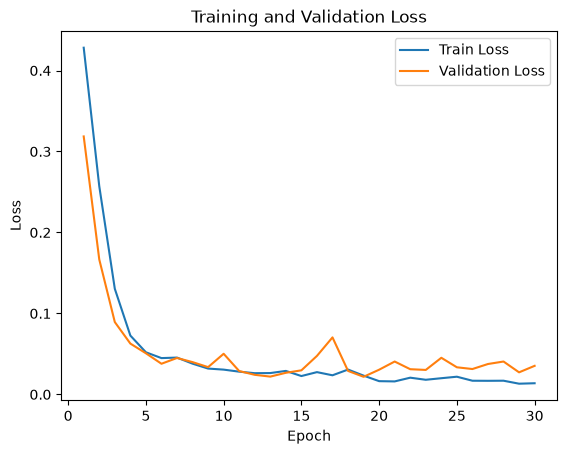

In [27]:
import matplotlib.pyplot as plt

epochs = range(1, config.epochs + 1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")

plt.plot(epochs, history["validation_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

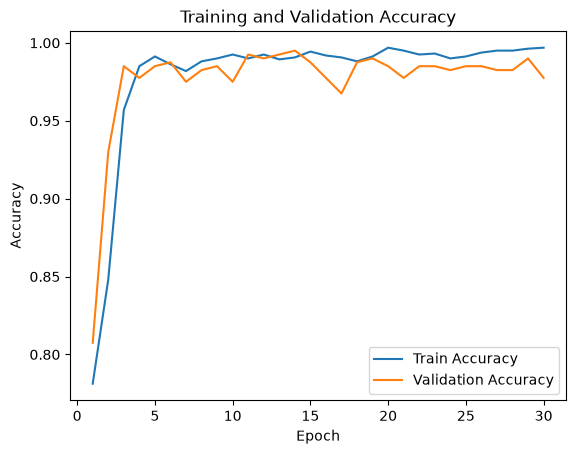

In [28]:
plt.figure()

plt.plot(epochs, history["train_accuracy"], label="Train Accuracy")
plt.plot(epochs, history["validation_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

## 32. 保存 Checkpoint 的真正意义

Checkpoint 不是为了“保存一个文件”。

真正目标是：

> 能够在一个新的 Model Object 中恢复训练得到的 Parameter。

因此必须实际进行 Reload Test。

如果从未尝试 Reload，就不能确认 Checkpoint 是否真的可用。

In [36]:
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

best_model = TinyClassifier(
    input_dim=config.input_dim,
    hidden_dim=config.hidden_dim,
    num_classes=config.num_classes,
).to(device)

best_model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["validation_loss"])

Loaded epoch: 19
Validation loss: 0.021740257143974304


In [37]:
(reloaded_validation_loss, reloaded_validation_accuracy) = evaluate(
    model=best_model, loader=validation_loader, criterion=criterion, device=device
)

print("Reloaded validation loss:", reloaded_validation_loss)
print("Reloaded validation accuracy:", reloaded_validation_accuracy)

Reloaded validation loss: 0.021740257143974304
Reloaded validation accuracy: 0.99


## 33. Inference Pipeline

Training：

```text
Input
→ Model
→ Logits
→ Loss
→ Backward
```

Inference：

```text
Input
→ Model
→ Logits
→ Prediction
```

不需要：

- Loss；
- Backward；
- Optimizer。

对于 Classification：

$$
\hat y
=
\arg\max(logits)
$$

In [38]:
best_model.eval()

example = torch.tensor(
    [
        [0.0, 0.0],
        [1.5, 0.0],
        [0.7, 0.7],
        [1.2, 1.2],
    ],
    dtype=torch.float32,
    device=device,
)

with torch.inference_mode():
    logits = best_model(example)

    probabilities = torch.softmax(logits, dim=-1)

    predictions = logits.argmax(dim=-1)

print("Input:")
print(example.cpu())

print("\nProbabilities:")
print(probabilities.cpu())

print("\nPredictions:")
print(predictions.cpu())


Input:
tensor([[0.0000, 0.0000],
        [1.5000, 0.0000],
        [0.7000, 0.7000],
        [1.2000, 1.2000]])

Probabilities:
tensor([[9.9889e-01, 1.1078e-03],
        [9.6898e-11, 1.0000e+00],
        [7.3714e-01, 2.6286e-01],
        [4.2958e-13, 1.0000e+00]])

Predictions:
tensor([0, 1, 0, 1])


## 34. Reference Test

CS336 后面大量实现都应该采用：

```text
Your Implementation
       vs
Reference Implementation
```

TinyClassifier 本身主要由 PyTorch Module 构成，所以这里做一个简单 Reference Test：

验证：

```python
argmax(logits)
```

与：

```python
argmax(softmax(logits))
```

给出完全相同的分类结果。

因为 Softmax 是单调变换，不会改变最大 Logit 的位置。

In [39]:
best_model.eval()

features_batch, _ = next(iter(validation_loader))
features_batch = features_batch.to(device)

with torch.inference_mode():
    logits = best_model(features_batch)

    predictions_from_logits = logits.argmax(dim=-1)
    predictions_from_probabilities = torch.softmax(logits, dim=-1).argmax(dim=-1)

assert torch.equal(predictions_from_logits, predictions_from_probabilities)

print("Reference test passed.")

Reference test passed.


## 35. Reproducibility Test

如果设置相同 Seed，并以完全相同顺序：

```text
初始化 Model
```

那么在同一环境中，我们通常希望初始 Parameter 一致。

这里测试：

```text
seed
→ model A
seed
→ model B
```

两者 Parameter 是否相同。

这不是完整 Training Reproducibility Test，但能够验证 Initialization Reproducibility。

In [40]:
set_seed(config.seed)
model_a = TinyClassifier(
    input_dim=config.input_dim,
    hidden_dim=config.hidden_dim,
    num_classes=config.num_classes,
)

set_seed(config.seed)
model_b = TinyClassifier(
    input_dim=config.input_dim,
    hidden_dim=config.hidden_dim,
    num_classes=config.num_classes,
)

for parameter_a, parameter_b in zip(
    model_a.parameters(), model_b.parameters(), strict=True
):
    assert torch.equal(parameter_a, parameter_b)

print("Initialization reproducibility test passed.")

Initialization reproducibility test passed.


## 36. 为什么 Overfit-One-Batch 非常重要？

这是以后做 CS336 时很值得保留的 Test。

假设完整模型训练失败：

```text
Loss 不下降
```

很难立刻知道问题在哪。

但如果只取一个很小的 Mini-Batch：

```text
固定 Data
反复训练
```

一个具有足够容量的 Model 通常应该能把这个 Batch 几乎记住。

如果连一个 Batch 都无法 Overfit：

> 很可能 Training Pipeline 存在结构性问题。

可能包括：

- Forward Bug
- Loss Bug
- Gradient Flow Bug
- Optimizer Bug
- Target Bug
- Training Loop Bug

因此：

```text
Can the model overfit one batch?
```

是非常高价值的 Debug Question。

In [41]:
set_seed(config.seed)

overfit_model = TinyClassifier(
    input_dim=config.input_dim,
    hidden_dim=config.hidden_dim,
    num_classes=config.num_classes,
).to(device)

overfit_optimizer = torch.optim.AdamW(
    overfit_model.parameters(), lr=1e-2, weight_decay=0.0
)

overfit_features, overfit_targets = next(iter(train_loader))
overfit_features = overfit_features.to(device)
overfit_targets = overfit_targets.to(device)

for step in range(300):
    overfit_optimizer.zero_grad(set_to_none=True)

    logits = overfit_model(overfit_features)

    loss = criterion(
        logits,
        overfit_targets,
    )
    loss.backward()
    overfit_optimizer.step()

    if step == 0 or (step + 1) % 50 == 0:
        with torch.inference_mode():
            predictions = logits.argmax(dim=-1)

            accuracy = (predictions == overfit_targets).float().mean().item()

        print(f"Step {step + 1:03d} | loss {loss.item():.6f} | accuracy {accuracy:.3f}")


Step 001 | loss 0.677230 | accuracy 0.453
Step 050 | loss 0.013515 | accuracy 1.000
Step 100 | loss 0.003167 | accuracy 1.000
Step 150 | loss 0.001125 | accuracy 1.000
Step 200 | loss 0.000537 | accuracy 1.000
Step 250 | loss 0.000312 | accuracy 1.000
Step 300 | loss 0.000205 | accuracy 1.000


## 37. Overfit Test 如何判断通过？

我们不强行要求：

```text
100.000000% accuracy
```

因为不同初始化、Batch 和硬件行为会带来小差异。

但应该看到一个非常明显的趋势：

```text
Loss 大幅下降
Accuracy 明显接近 1
```

如果完全没有这种趋势，就不要急着增加 Epoch。

先检查 Training Pipeline。

以后写 Transformer 时，也可以做：

```text
极小 Vocabulary
极小 Sequence
极小 Batch
固定几个 Samples
反复训练
```

如果 Tiny Transformer 连这些样本都学不会，就应该先 Debug，而不是启动大规模训练。

## 38. Mini Project Validator

现在把多个 Sanity Check 汇总到一起。

一个有用的 Validator 不应该只检查：

```text
代码能运行
```

而应该尽可能检查不变量：

```text
Correct Shape
Finite Values
Valid Accuracy
Valid Loss
Checkpoint Exists
Model Parameters Exist
```

这种思维后面做 CS336 Assignment Tests 会非常重要。

In [42]:
def validate_experiment(
    model: nn.Module,
    history: dict[str, list[float]],
    checkpoint_path: Path,
    config: Config,
) -> None:
    assert checkpoint_path.exists()

    assert len(history["train_loss"]) == config.epochs
    assert len(history["validation_loss"]) == config.epochs

    for key, values in history.items():
        assert len(values) == config.epochs
        assert all(math.isfinite(value) for value in values), key

    assert all(0.0 <= value <= 1.0 for value in history["train_accuracy"])
    assert all(0.0 <= value <= 1.0 for value in history["validation_accuracy"])

    num_parameters = sum(parameter.numel() for parameter in model.parameters())

    assert num_parameters > 0

    print("Experiment validation passed.")


validate_experiment(
    model=best_model, history=history, checkpoint_path=checkpoint_path, config=config
)


Experiment validation passed.


## 39. 从头到尾重新看一次

现在完整 Training Pipeline 是：

```text
Config
  ↓
Seed
  ↓
Device
  ↓
Dataset
  ↓
Data Sanity Check
  ↓
Train / Validation Split
  ↓
Dataset Object
  ↓
DataLoader
  ↓
Mini-Batch
  ↓
Model
  ↓
Forward
  ↓
Logits
  ↓
Cross Entropy Loss
  ↓
Backward
  ↓
Gradient
  ↓
AdamW
  ↓
Parameter Update
  ↓
Repeat over Mini-Batches
  ↓
One Epoch
  ↓
Evaluation
  ↓
Metrics
  ↓
Best Validation Checkpoint
  ↓
Reload
  ↓
Inference
  ↓
Reference Test
  ↓
Reproducibility Test
  ↓
Overfit-One-Batch Test
  ↓
Validator
```

现在你已经第一次拥有了一套完整 Deep Learning Experiment Workflow。

## 40. 五行代码背后的完整含义

以后你会无数次看到：

```python
optimizer.zero_grad()

logits = model(features)

loss = criterion(
    logits,
    targets,
)

loss.backward()

optimizer.step()
```

不要把它理解成五个 API。

它实际上对应：

```text
清除上一个 Step 的 Gradient
        ↓
执行 Forward Computation
        ↓
构造 Scalar Objective
        ↓
Reverse-Mode Automatic Differentiation
        ↓
得到每个 Parameter 的 Gradient
        ↓
Optimizer 根据 Gradient + State
更新 Parameter
```

换成数学形式：

$$
\theta_t
$$

经过 Forward 得到：

$$
L(\theta_t)
$$

Backward 得到：

$$
g_t
=
\nabla_\theta L(\theta_t)
$$

Optimizer：

$$
\theta_{t+1}
=
Update(
\theta_t,
g_t,
state_t
)
$$

这就是之后所有 Transformer Training 的基本骨架。

## 41. 本项目最重要的 Shape

### Dataset

$$
features.shape=(N,2)
$$

$$
targets.shape=(N,)
$$

### Single Sample

```text
feature: (2,)
target : ()
```

### Mini-Batch

$$
X.shape=(B,2)
$$

$$
y.shape=(B,)
$$

### Hidden Layer

$$
(B,2)
\rightarrow
(B,H)
$$

### Logits

$$
(B,H)
\rightarrow
(B,2)
$$

### Cross Entropy

输入：

```text
logits : (B, 2)
targets: (B,)
```

输出：

```text
loss: ()
```

这个 Shape Pipeline 必须可以不运行代码直接推出。


## 42. 常见错误

### 错误 1：最后一层手动 Softmax

错误思维：

```text
Classifier output
→ 必须先 Softmax
→ CrossEntropyLoss
```

正确：

```text
Raw Logits
→ CrossEntropyLoss
```

---

### 错误 2：Target 使用 Float

Classification class-index target 应该是 Integer：

```python
torch.long
```

---

### 错误 3：Target 做成 `(B, 1)`

标准 class-index target：

```text
(B,)
```

---

### 错误 4：忘记 `zero_grad`

PyTorch 默认累积 Gradient。

---

### 错误 5：Validation 时仍然调用 `backward()`

Validation：

```text
No Parameter Update
```

---

### 错误 6：只看 Training Loss

应该同时看：

```text
Train
vs
Validation
```

---

### 错误 7：Checkpoint 保存了但从未 Reload

保存成功不代表恢复一定成功。

必须做 Reload Test。

---

### 错误 8：Loss 不下降就立刻增加训练时间

正确顺序：

```text
Data
→ Shape
→ Forward
→ Loss
→ Gradient
→ Optimizer
→ Overfit One Batch
→ 再考虑 Hyperparameters
```